# MSCS-634: Advanced Big Data and Data Mining
### Lab 1: Data Visualization, Preprocessing, and Statistical Analysis
**Name:** Samia Zaman

**Dataset:** Synthetic retail sales dataset (generated for this lab, modeled on typical
e-commerce order data: date, region, product category, units sold, price, discount,
customer age, and revenue). Missing values and outliers were intentionally injected
so the preprocessing steps below have real issues to work with.


## Step 1: Data Collection

The dataset used in this lab is a synthetic retail sales dataset built to resemble
typical e-commerce order data (similar in spirit to Kaggle sales datasets). It was
generated with `generate_dataset.py` in this folder and saved to `data/retail_sales.csv`.
Missing values and a handful of outliers were deliberately injected so the
preprocessing steps later in the notebook have real problems to solve.

Columns:
- `Order_ID` - unique order identifier
- `Order_Date` - date the order was placed
- `Region` - North / South / East / West
- `Product_Category` - Electronics / Clothing / Home & Garden / Sports / Toys
- `Units_Sold` - number of units in the order
- `Unit_Price` - price per unit (USD)
- `Discount_Percent` - discount applied to the order
- `Customer_Age` - age of the customer
- `Sales_Revenue` - total revenue for the order


In [5]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("data/retail_sales.csv", parse_dates=["Order_Date"])
df.shape


(1000, 9)

**First five rows of the dataset:**

In [2]:
df.head()

,Order_ID,Order_Date,Region,Product_Category,Units_Sold,Unit_Price,Discount_Percent,Customer_Age,Sales_Revenue
0,1845,2024-01-03,South,Sports,5,69.32,6.7,38.0,323.38
1,1381,2024-01-03,North,Toys,8,31.27,26.1,20.0,184.87
2,1901,2024-01-03,East,Home & Garden,6,82.84,0.1,30.0,496.54
3,1846,2024-01-03,South,Sports,6,52.35,20.9,20.0,248.45
4,1773,2024-01-03,North,Clothing,11,42.11,20.5,41.0,368.25


## Step 2: Data Visualization

### 2.1 Scatter Plot - Units Sold vs. Sales Revenue

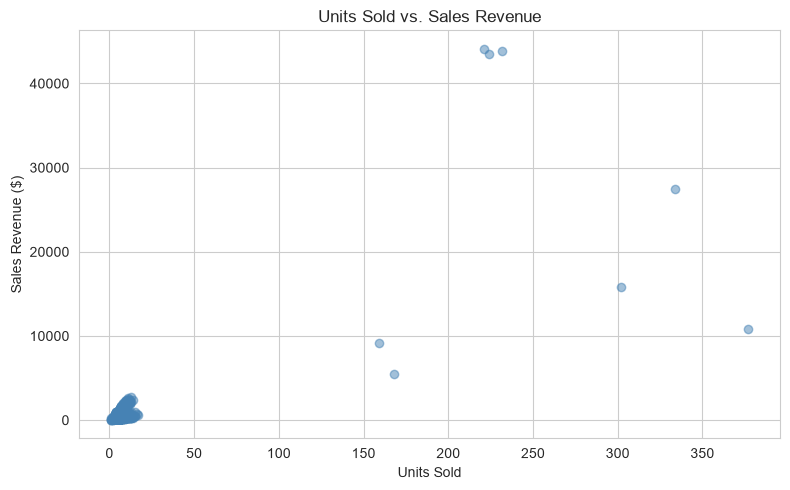

In [3]:
plt.figure()
plt.scatter(df["Units_Sold"], df["Sales_Revenue"], alpha=0.5, color="steelblue")
plt.xlabel("Units Sold")
plt.ylabel("Sales Revenue ($)")
plt.title("Units Sold vs. Sales Revenue")
plt.tight_layout()
plt.savefig("screenshots/02_scatter_units_vs_revenue.png", dpi=150)
plt.show()


**Insight:** Revenue increases roughly linearly with units sold for most orders, which makes
sense since revenue is derived from units and price. The handful of points far to the right
(orders with 150+ units) are the outliers we injected into the dataset, and they clearly stand
apart from the main cluster.


### 2.2 Line Plot - Monthly Sales Revenue Trend

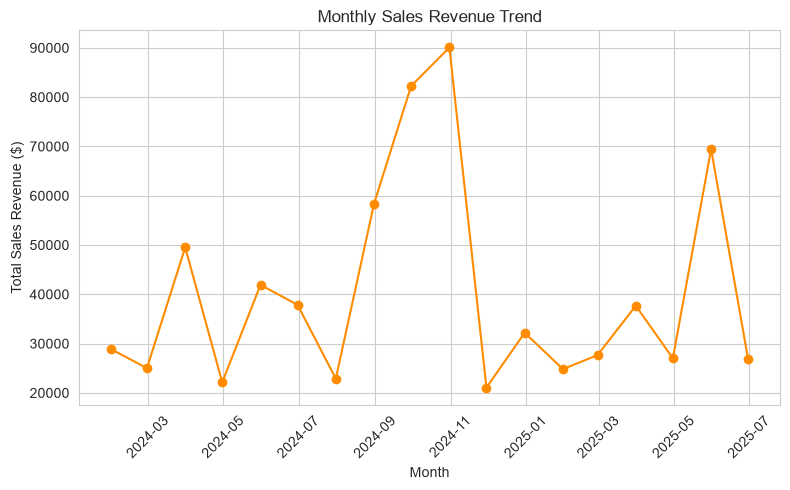

In [4]:
monthly_revenue = df.set_index("Order_Date").resample("ME")["Sales_Revenue"].sum()

plt.figure()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="darkorange")
plt.xlabel("Month")
plt.ylabel("Total Sales Revenue ($)")
plt.title("Monthly Sales Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("screenshots/03_line_monthly_revenue.png", dpi=150)
plt.show()


**Insight:** Monthly revenue fluctuates but stays in a broadly similar range across the
period, without a strong upward or downward trend. This is expected since the data was
generated without a seasonal or growth pattern - in a real business dataset, this plot is
where you'd look for seasonality or growth trends.


### 2.3 Bar Chart - Total Revenue by Product Category

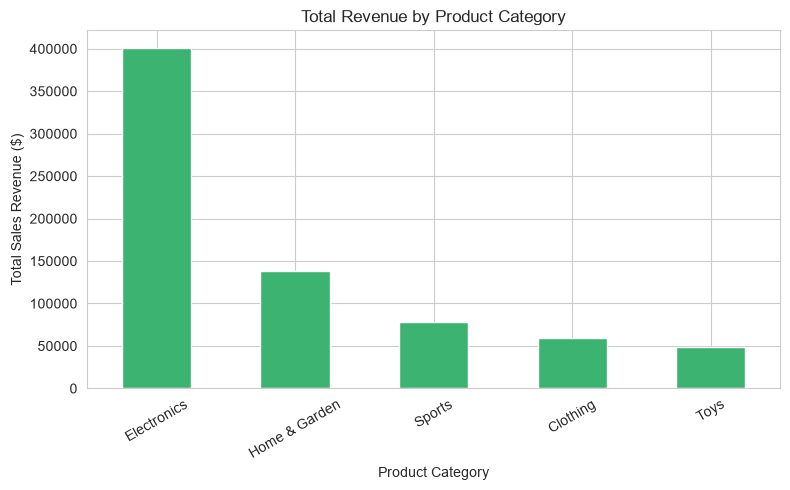

In [5]:
category_revenue = df.groupby("Product_Category")["Sales_Revenue"].sum().sort_values(ascending=False)

plt.figure()
category_revenue.plot(kind="bar", color="mediumseagreen")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Revenue ($)")
plt.title("Total Revenue by Product Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("screenshots/04_bar_category_revenue.png", dpi=150)
plt.show()


**Insight:** Electronics generates noticeably more total revenue than the other categories,
which tracks with it having the highest unit price in the dataset. Toys and Clothing bring in
the least, driven by their lower price points.


### 2.4 Histogram - Distribution of Customer Age

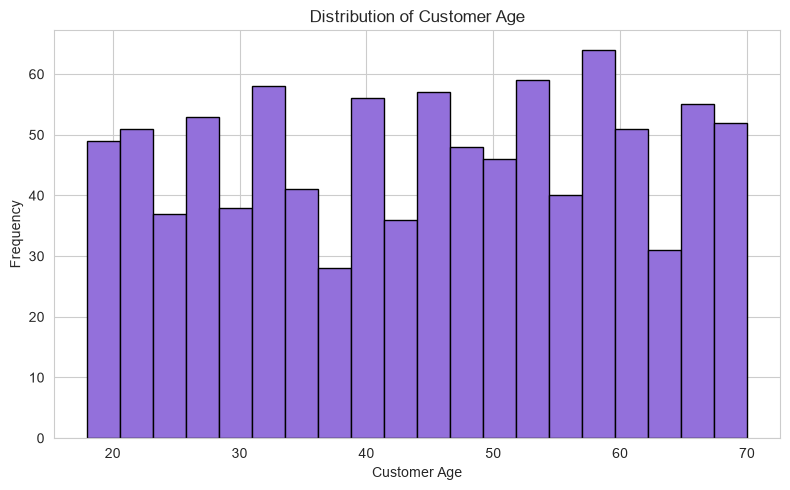

In [6]:
plt.figure()
df["Customer_Age"].dropna().plot(kind="hist", bins=20, color="mediumpurple", edgecolor="black")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Age")
plt.tight_layout()
plt.savefig("screenshots/05_hist_customer_age.png", dpi=150)
plt.show()


**Insight:** Customer age is roughly uniformly distributed between 18 and 70, which matches how
the synthetic data was generated. There's no strong skew or concentration around a particular
age group.


### 2.5 Box Plot - Sales Revenue by Product Category

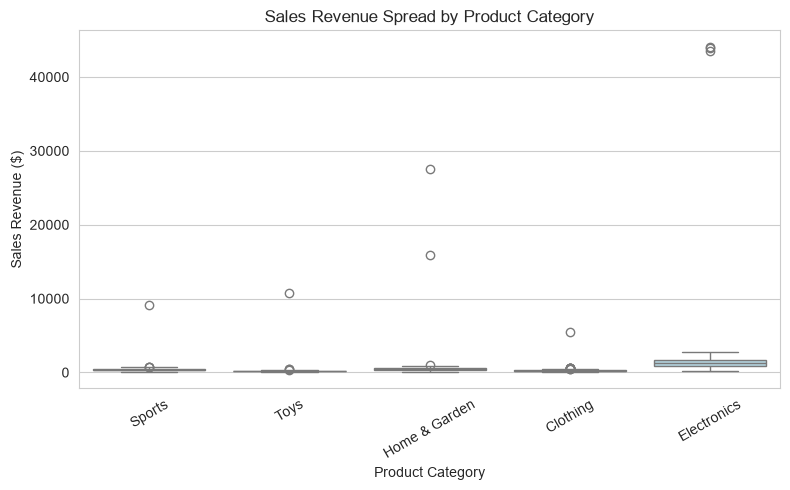

In [7]:
plt.figure()
sns.boxplot(data=df, x="Product_Category", y="Sales_Revenue", color="lightblue")
plt.xlabel("Product Category")
plt.ylabel("Sales Revenue ($)")
plt.title("Sales Revenue Spread by Product Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("screenshots/06_box_revenue_by_category.png", dpi=150)
plt.show()


**Insight:** Electronics has both the highest median revenue and the widest spread, with several
high-value outlier orders visible above the whiskers. The other categories are more tightly
clustered near the lower end of the revenue scale.


### 2.6 Pie Chart - Share of Orders by Region

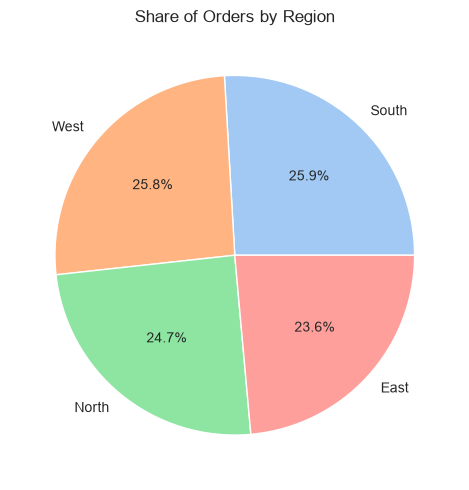

In [8]:
region_counts = df["Region"].value_counts()

plt.figure()
plt.pie(region_counts.values, labels=region_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("pastel"))
plt.title("Share of Orders by Region")
plt.tight_layout()
plt.savefig("screenshots/07_pie_region_share.png", dpi=150)
plt.show()


**Insight:** Orders are split fairly evenly across the four regions, each landing close to 25%
of the total, which is consistent with the random region assignment used when the data was
generated.


## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [9]:
print("Missing values per column (before handling):")
df.isna().sum()


Missing values per column (before handling):


Order_ID             0
Order_Date           0
Region              20
Product_Category     0
Units_Sold           0
Unit_Price           0
Discount_Percent    40
Customer_Age        50
Sales_Revenue        0
dtype: int64

In [10]:
df_before_missing = df.copy()
df_before_missing.head(10)


,Order_ID,Order_Date,Region,Product_Category,Units_Sold,Unit_Price,Discount_Percent,Customer_Age,Sales_Revenue
0,1845,2024-01-03,South,Sports,5,69.32,6.7,38.0,323.38
1,1381,2024-01-03,North,Toys,8,31.27,26.1,20.0,184.87
2,1901,2024-01-03,East,Home & Garden,6,82.84,0.1,30.0,496.54
3,1846,2024-01-03,South,Sports,6,52.35,20.9,20.0,248.45
4,1773,2024-01-03,North,Clothing,11,42.11,20.5,41.0,368.25
5,1575,2024-01-04,West,Electronics,8,236.46,14.4,42.0,1619.28
6,1465,2024-01-04,South,Toys,4,25.88,27.5,25.0,75.05
7,1707,2024-01-05,East,Toys,8,33.21,3.2,39.0,257.18
8,1104,2024-01-05,North,Electronics,3,244.66,24.5,43.0,554.15
9,1303,2024-01-06,East,Sports,3,58.54,7.5,39.0,162.45


In [11]:
df_clean = df.copy()

# Region: categorical column with a small number of missing values -> fill with mode
df_clean["Region"] = df_clean["Region"].fillna(df_clean["Region"].mode()[0])

# Discount_Percent: fill with the mean discount
df_clean["Discount_Percent"] = df_clean["Discount_Percent"].fillna(df_clean["Discount_Percent"].mean())

# Customer_Age: fill with the median age (robust to outliers/skew)
df_clean["Customer_Age"] = df_clean["Customer_Age"].fillna(df_clean["Customer_Age"].median())

print("Missing values per column (after handling):")
df_clean.isna().sum()


Missing values per column (after handling):


Order_ID            0
Order_Date          0
Region              0
Product_Category    0
Units_Sold          0
Unit_Price          0
Discount_Percent    0
Customer_Age        0
Sales_Revenue       0
dtype: int64

In [12]:
df_clean.head(10)

,Order_ID,Order_Date,Region,Product_Category,Units_Sold,Unit_Price,Discount_Percent,Customer_Age,Sales_Revenue
0,1845,2024-01-03,South,Sports,5,69.32,6.7,38.0,323.38
1,1381,2024-01-03,North,Toys,8,31.27,26.1,20.0,184.87
2,1901,2024-01-03,East,Home & Garden,6,82.84,0.1,30.0,496.54
3,1846,2024-01-03,South,Sports,6,52.35,20.9,20.0,248.45
4,1773,2024-01-03,North,Clothing,11,42.11,20.5,41.0,368.25
5,1575,2024-01-04,West,Electronics,8,236.46,14.4,42.0,1619.28
6,1465,2024-01-04,South,Toys,4,25.88,27.5,25.0,75.05
7,1707,2024-01-05,East,Toys,8,33.21,3.2,39.0,257.18
8,1104,2024-01-05,North,Electronics,3,244.66,24.5,43.0,554.15
9,1303,2024-01-06,East,Sports,3,58.54,7.5,39.0,162.45


**Notes:** `Region` (categorical) was filled with its mode, `Discount_Percent` was filled with
its mean, and `Customer_Age` was filled with its median since age can be slightly skewed by a
few older customers. No rows or columns were dropped here since the missing rate for each
column was low (2-5%), so imputing preserves more of the dataset than dropping would.


### 3.2 Outlier Detection and Removal (IQR method)

In [13]:
Q1 = df_clean["Sales_Revenue"].quantile(0.25)
Q3 = df_clean["Sales_Revenue"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

outliers = df_clean[(df_clean["Sales_Revenue"] < lower_bound) | (df_clean["Sales_Revenue"] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")
outliers[["Order_ID", "Units_Sold", "Unit_Price", "Sales_Revenue"]]


Q1: 221.57, Q3: 610.43, IQR: 388.86
Lower bound: -361.72, Upper bound: 1193.73

Number of outliers detected: 121


,Order_ID,Units_Sold,Unit_Price,Sales_Revenue
5,1575,8,236.46,1619.28
10,1801,10,250.58,1962.04
14,1889,11,230.99,1778.62
19,1300,12,226.02,2218.61
28,1787,11,216.32,2082.08
...,...,...,...,...
908,1642,232,214.62,43866.61
933,1286,9,242.35,1648.95
949,1763,9,233.82,1885.52
969,1466,8,247.34,1638.38


In [14]:
df_no_outliers = df_clean[(df_clean["Sales_Revenue"] >= lower_bound) & (df_clean["Sales_Revenue"] <= upper_bound)].copy()

print(f"Rows before outlier removal: {len(df_clean)}")
print(f"Rows after outlier removal: {len(df_no_outliers)}")
df_no_outliers.describe()[["Sales_Revenue"]]


Rows before outlier removal: 1000
Rows after outlier removal: 879


,Sales_Revenue
count,879.000000
mean,378.934653
min,47.040000
25%,205.700000
50%,315.150000
75%,495.185000
max,1175.250000
std,240.198572


**Notes:** The IQR method on `Sales_Revenue` flagged 121 orders (about 12% of the data) as
outliers, including the extreme 150-400 unit orders that were injected on purpose. The rest
are naturally high-revenue orders - `Sales_Revenue` is right-skewed (a small number of orders
combine high unit price and high quantity), so a meaningful chunk of the upper tail falls
outside the 1.5x IQR fence even without any injected anomalies. All flagged rows were removed
here to keep the remaining analysis focused on typical orders, though in practice it would also
be reasonable to only remove the most extreme injected outliers and keep the natural tail.


### 3.3 Data Reduction

In [15]:
print(f"Dataset shape before reduction: {df_no_outliers.shape}")

# Sampling: reduce to 40% of the rows
df_sampled = df_no_outliers.sample(frac=0.4, random_state=42).reset_index(drop=True)
print(f"Dataset shape after sampling (40%): {df_sampled.shape}")

# Dimension elimination: Order_ID is just an identifier, not useful for analysis
df_reduced = df_sampled.drop(columns=["Order_ID"])
print(f"Dataset shape after dropping Order_ID column: {df_reduced.shape}")

df_reduced.head()


Dataset shape before reduction: (879, 9)
Dataset shape after sampling (40%): (352, 9)
Dataset shape after dropping Order_ID column: (352, 8)


,Order_Date,Region,Product_Category,Units_Sold,Unit_Price,Discount_Percent,Customer_Age,Sales_Revenue
0,2024-08-10,West,Home & Garden,15,81.61,23.2,48.0,940.15
1,2024-06-04,North,Home & Garden,8,89.02,11.1,52.0,633.11
2,2025-05-14,West,Toys,14,34.07,13.1,36.0,414.50
3,2024-07-23,South,Clothing,8,52.01,21.6,44.0,326.21
4,2024-05-13,North,Toys,5,32.22,19.8,39.0,129.20


**Notes:** The dataset was sampled down to 40% of its rows to demonstrate size reduction while
keeping the sample large enough to remain statistically meaningful. `Order_ID` was dropped
since it is a unique identifier with no analytical value.


### 3.4 Data Scaling and Discretization

In [17]:
df_scaled = df_reduced.copy()

# Min-Max scaling on Sales_Revenue -> range [0, 1]
min_rev, max_rev = df_scaled["Sales_Revenue"].min(), df_scaled["Sales_Revenue"].max()
df_scaled["Sales_Revenue_MinMax"] = (df_scaled["Sales_Revenue"] - min_rev) / (max_rev - min_rev)

# Z-score standardization on Unit_Price
mean_price, std_price = df_scaled["Unit_Price"].mean(), df_scaled["Unit_Price"].std()
df_scaled["Unit_Price_Zscore"] = (df_scaled["Unit_Price"] - mean_price) / std_price

# Discretization: bin Customer_Age into meaningful categories
df_scaled["Age_Group"] = pd.cut(
    df_scaled["Customer_Age"],
    bins=[0, 30, 50, 100],
    labels=["Young (<=30)", "Middle-aged (31-50)", "Senior (51+)"]
)

df_scaled[["Sales_Revenue", "Sales_Revenue_MinMax", "Unit_Price", "Unit_Price_Zscore",
           "Customer_Age", "Age_Group"]].head(10)


,Sales_Revenue,Sales_Revenue_MinMax,Unit_Price,Unit_Price_Zscore,Customer_Age,Age_Group
0,940.15,0.791617,81.61,0.125250,48.0,Middle-aged (31-50)
1,633.11,0.519469,89.02,0.258691,52.0,Senior (51+)
2,414.50,0.325702,34.07,-0.730858,36.0,Middle-aged (31-50)
3,326.21,0.247445,52.01,-0.407791,44.0,Middle-aged (31-50)
4,129.20,0.072823,32.22,-0.764173,39.0,Middle-aged (31-50)
5,178.32,0.116361,40.00,-0.624069,69.0,Senior (51+)
6,360.10,0.277484,54.76,-0.358269,70.0,Senior (51+)
7,176.94,0.115138,71.06,-0.064736,55.0,Senior (51+)
8,363.18,0.280214,230.74,2.810807,50.0,Middle-aged (31-50)
9,168.31,0.107489,43.74,-0.556719,56.0,Senior (51+)


**Notes:** `Sales_Revenue` was Min-Max scaled to [0, 1] so it can be compared on the same scale
as other normalized features. `Unit_Price` was standardized with a Z-score so its mean is 0 and
standard deviation is 1. `Customer_Age` was discretized into three meaningful groups
(Young / Middle-aged / Senior) for easier categorical analysis.


## Step 4: Statistical Analysis

### 4.1 General Overview of Data

In [18]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_Date            352 non-null    datetime64[us]
 1   Region                352 non-null    str           
 2   Product_Category      352 non-null    str           
 3   Units_Sold            352 non-null    int64         
 4   Unit_Price            352 non-null    float64       
 5   Discount_Percent      352 non-null    float64       
 6   Customer_Age          352 non-null    float64       
 7   Sales_Revenue         352 non-null    float64       
 8   Sales_Revenue_MinMax  352 non-null    float64       
 9   Unit_Price_Zscore     352 non-null    float64       
 10  Age_Group             352 non-null    category      
dtypes: category(1), datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 28.1 KB


In [19]:
df_scaled.describe()

,Order_Date,Units_Sold,Unit_Price,Discount_Percent,Customer_Age,Sales_Revenue,Sales_Revenue_MinMax,Unit_Price_Zscore
count,352,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,3.520000e+02
mean,2024-09-27 06:32:43.636363,6.883523,74.654801,15.132028,45.343750,399.092443,0.312045,-1.488708e-16
min,2024-01-03 00:00:00,1.000000,25.580000,0.000000,18.000000,47.040000,0.000000,-8.837468e-01
25%,2024-05-11 00:00:00,5.000000,40.567500,6.800000,33.000000,216.992500,0.150639,-6.138495e-01
50%,2024-09-29 12:00:00,7.000000,60.235000,15.300000,45.000000,334.660000,0.254935,-2.596741e-01
75%,2025-02-05 06:00:00,8.000000,81.490000,22.125000,57.000000,524.662500,0.423345,1.230893e-01
max,2025-06-28 00:00:00,17.000000,260.060000,29.900000,70.000000,1175.250000,1.000000,3.338806e+00
std,NaN,2.652862,55.530389,8.854466,14.600219,248.897134,0.220612,1.000000e+00


### 4.2 Central Tendency Measures

In [20]:
numeric_cols = ["Units_Sold", "Unit_Price", "Discount_Percent", "Customer_Age", "Sales_Revenue"]

central_tendency = pd.DataFrame({
    "Minimum": df_scaled[numeric_cols].min(),
    "Maximum": df_scaled[numeric_cols].max(),
    "Mean": df_scaled[numeric_cols].mean(),
    "Median": df_scaled[numeric_cols].median(),
    "Mode": df_scaled[numeric_cols].mode().iloc[0],
})
central_tendency


,Minimum,Maximum,Mean,Median,Mode
Units_Sold,1.00,17.00,6.883523,7.000,6.000000
Unit_Price,25.58,260.06,74.654801,60.235,25.830000
Discount_Percent,0.00,29.90,15.132028,15.300,14.698125
Customer_Age,18.00,70.00,45.343750,45.000,45.000000
Sales_Revenue,47.04,1175.25,399.092443,334.660,47.040000


### 4.3 Dispersion Measures

In [20]:
dispersion = pd.DataFrame({
    "Range": df_scaled[numeric_cols].max() - df_scaled[numeric_cols].min(),
    "Q1": df_scaled[numeric_cols].quantile(0.25),
    "Q3": df_scaled[numeric_cols].quantile(0.75),
    "IQR": df_scaled[numeric_cols].quantile(0.75) - df_scaled[numeric_cols].quantile(0.25),
    "Variance": df_scaled[numeric_cols].var(),
    "Std_Dev": df_scaled[numeric_cols].std(),
})
dispersion


,Range,Q1,Q3,IQR,Variance,Std_Dev
Units_Sold,16.00,5.0000,8.0000,3.0000,7.037676,2.652862
Unit_Price,234.48,40.5675,81.4900,40.9225,3083.624073,55.530389
Discount_Percent,29.90,6.8000,22.1250,15.3250,78.401567,8.854466
Customer_Age,52.00,33.0000,57.0000,24.0000,213.166400,14.600219
Sales_Revenue,1128.21,216.9925,524.6625,307.6700,61949.783371,248.897134


### 4.4 Correlation Analysis

In [21]:
correlation_matrix = df_scaled[numeric_cols].corr()
correlation_matrix


,Units_Sold,Unit_Price,Discount_Percent,Customer_Age,Sales_Revenue
Units_Sold,1.000000,-0.274431,0.022516,0.052232,0.303515
Unit_Price,-0.274431,1.000000,0.103120,-0.051470,0.757020
Discount_Percent,0.022516,0.103120,1.000000,0.029291,-0.050494
Customer_Age,0.052232,-0.051470,0.029291,1.000000,-0.015057
Sales_Revenue,0.303515,0.757020,-0.050494,-0.015057,1.000000


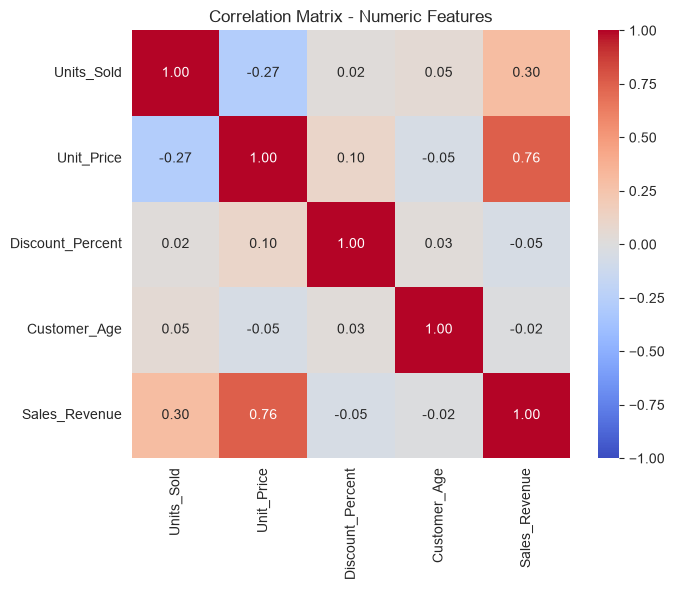

In [22]:
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.savefig("screenshots/16_correlation_heatmap.png", dpi=150)
plt.show()


**Insight:** `Unit_Price` and `Sales_Revenue` show the strongest positive correlation
(around 0.76), which makes sense since higher-priced items drive up order revenue.
`Units_Sold` is only moderately correlated with `Sales_Revenue` (around 0.30) - more units
help, but price has a bigger effect on revenue in this dataset. `Discount_Percent` has close
to no correlation with `Sales_Revenue`, and `Customer_Age` shows essentially no correlation
with any of the other variables, since it was generated independently of purchase behavior.


## Summary

This notebook walked through loading a retail sales dataset, visualizing it with six different
chart types, cleaning it up (missing values, outliers, reduction, scaling/discretization), and
computing summary statistics and correlations. See `README.md` for a discussion of the overall
insights and the decisions made along the way.
